# Photon Count & Fluence Analysis

**Purpose:** Characterise the detected photon population from MCX simulations across
chest-wall thicknesses (10–35 mm) and source–detector separations (SDS 5–35 mm).

**Analysis pipeline:**
1. Load simulation data (`detp` arrays) for each chest-wall thickness
2. Count detected photons per detector and per tissue layer
3. Compute **air-hit percentage** — the fraction of detected photons that traversed the lung air space
4. Visualise counts, layer fractions, and SDS/CW trends

---
**`detp` row mapping (MCX output):**

| Row | Content |
|-----|---------|
| 0 | Detector ID (1-based) |
| 1 | Lung tissue step count |
| 2 | Air (lung gas) step count |
| 3 | Chest-wall (thorax) step count |

A photon **hit air** if its air step count (row 2) > 0.
Only these photons carry the GASMAS O₂ absorption signal.


## 1. Environment Setup


In [ ]:
%pip install --upgrade matplotlib pyparsing

# Mount Google Drive (comment out if running locally)
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Global parameters ────────────────────────────────────────────────
SDS_LIST_MM     = [5, 10, 15, 20, 25, 30,35]   # source-detector separations [mm]
CW_THICKNESSES  = [10, 15, 20, 25, 30,35]       # chest-wall thicknesses [mm]
CW_LABELS       = [f'{t} mm' for t in CW_THICKNESSES]
DATA_ROOT       = '/content/drive/MyDrive/GASMAS_Corrected/External'

# Colour map shared across all multi-CW plots
CMAP = plt.cm.tab10
CW_COLORS = {f'{t}mm': CMAP(i / 8) for i, t in enumerate(CW_THICKNESSES)}


## 2. Load MCX Simulation Data

Each `.npz` file contains the `detp` detected-photon array and the `fluence` volume.
We load all chest-wall thicknesses into a single dictionary for clean downstream access.


In [ ]:
detp_raw    = {}
fluence_raw = {}

for t in CW_THICKNESSES:
    key  = f'{t}mm'
    path = f'{DATA_ROOT}/gasmas_simulation_results_{t}mm.npz'
    with np.load(path) as d:
        detp_raw[key]    = d['detp'].copy()
        fluence_raw[key] = d['fluence'].copy()
    print(f'  Loaded {key}: {detp_raw[key].shape[1]:,} total detected photons')

print(f'\nAll datasets loaded: {list(detp_raw.keys())}')


  Loaded 10mm: 504,031 total detected photons
  Loaded 15mm: 497,892 total detected photons
  Loaded 20mm: 494,443 total detected photons
  Loaded 25mm: 493,504 total detected photons
  Loaded 30mm: 492,306 total detected photons
  Loaded 35mm: 493,377 total detected photons

All datasets loaded: ['10mm', '15mm', '20mm', '25mm', '30mm', '35mm']


## 3. Group Photons by Detector & Compute Layer Counts

Each detected photon is assigned to a detector via row 0 of `detp`.
For each detector we count how many photons visited each tissue layer,
and how many were **thorax-only** (never reached lung or air).


In [ ]:
def group_by_detector(detp):
    out = {}
    for det_id in np.unique(detp[0].astype(int)):
        out[det_id] = detp[:, detp[0].astype(int) == det_id]
    return out


def layer_counts(grouped):

    rows = []
    for det_id in sorted(grouped.keys()):
        ph = grouped[det_id]
        n_tot          = ph.shape[1]
        n_lung         = int(np.count_nonzero(ph[1] > 0))
        n_air          = int(np.count_nonzero(ph[2] > 0))
        n_thorax       = int(np.count_nonzero(ph[3] > 0))
        n_thorax_only  = int(np.count_nonzero(
                            (ph[3] > 0) & (ph[2] == 0) & (ph[1] == 0)))

        sds = SDS_LIST_MM[det_id - 1] if det_id - 1 < len(SDS_LIST_MM) else None

        def pct(n): return 100.0 * n / n_tot if n_tot > 0 else 0.0

        rows.append({
            'det_id'        : det_id,
            'sds'           : sds,
            'n_total'       : n_tot,
            'n_lung'        : n_lung,
            'n_air'         : n_air,
            'n_thorax'      : n_thorax,
            'n_thorax_only' : n_thorax_only,
            'pct_air'       : pct(n_air),
            'pct_lung'      : pct(n_lung),
            'pct_thorax'    : pct(n_thorax),
            'pct_thorax_only': pct(n_thorax_only),
        })
    return rows


# Group and compute for every CW thickness
detp_grouped = {k: group_by_detector(v) for k, v in detp_raw.items()}
counts       = {k: layer_counts(detp_grouped[k]) for k in detp_grouped}

print('Photon grouping complete.')


Photon grouping complete.


## 4. Photon Count Summary Tables

Full breakdown per detector and chest-wall thickness.
**Air-hit %** is the key metric: it tells us what fraction of detected photons
carried the GASMAS O₂ signal.


In [ ]:
HDR = (f"{'CW':<6} {'SDS':>5}  {'N_total':>9}  {'N_air':>8}  "
       f"{'Air %':>7}  {'N_lung':>8}  {'Lung %':>7}  "
       f"{'N_thorax':>9}  {'Thorax %':>9}  {'N_thorax_only':>14}  {'ThoraxOnly %':>13}")

print(HDR)
print('=' * len(HDR))

for cw in sorted(counts.keys()):
    for r in counts[cw]:
        print(
            f"{cw:<6} {r['sds']:>5}  {r['n_total']:>9,}  {r['n_air']:>8,}  "
            f"{r['pct_air']:>6.2f}%  {r['n_lung']:>8,}  {r['pct_lung']:>6.2f}%  "
            f"{r['n_thorax']:>9,}  {r['pct_thorax']:>8.2f}%  "
            f"{r['n_thorax_only']:>14,}  {r['pct_thorax_only']:>12.2f}%"
        )
    print()


CW       SDS    N_total     N_air    Air %    N_lung   Lung %   N_thorax   Thorax %   N_thorax_only   ThoraxOnly %
10mm       5    420,328    20,168    4.80%    22,859    5.44%    420,328    100.00%         397,469         94.56%
10mm      10     55,300    14,302   25.86%    15,879   28.71%     55,300    100.00%          39,421         71.29%
10mm      15     16,661     8,674   52.06%     9,379   56.29%     16,661    100.00%           7,282         43.71%
10mm      20      6,515     4,734   72.66%     5,007   76.85%      6,515    100.00%           1,508         23.15%
10mm      25      3,103     2,659   85.69%     2,754   88.75%      3,103    100.00%             349         11.25%
10mm      30      1,499     1,398   93.26%     1,422   94.86%      1,499    100.00%              77          5.14%
10mm      35        625       599   95.84%       609   97.44%        625    100.00%              16          2.56%

15mm       5    416,554     6,930    1.66%     7,628    1.83%    416,554    100

## 5. Visualisations

Five complementary plots:
- **5a** Total detected photon counts vs. SDS
- **5b** Air-hit photon counts vs. SDS
- **5c** **Air-hit percentage** vs. SDS ← key new analysis
- **5d** Stacked-bar breakdown of layer fractions per detector
- **5e** Thorax-only photon counts vs. SDS (noise / background)


### 5a. Total Detected Photon Counts vs. SDS

Photon counts fall with SDS as fewer photons reach distant detectors.
Thicker chest walls attenuate more strongly, especially at large SDS.


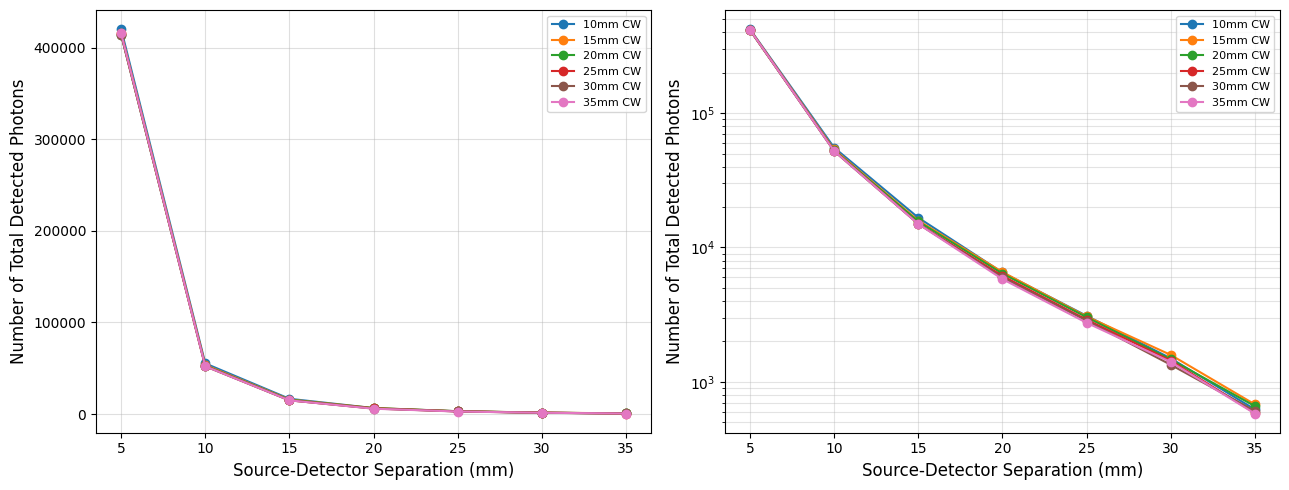

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    for cw in sorted(counts.keys()):
        sds_vals = [r['sds']     for r in counts[cw]]
        n_vals   = [r['n_total'] for r in counts[cw]]
        ax.plot(sds_vals, n_vals, marker='o',
                color=CW_COLORS[cw], label=f'{cw} CW')
    ax.set_xlabel('Source-Detector Separation (mm)', fontsize=12)
    ax.set_ylabel('Number of Total Detected Photons', fontsize=12)
    ax.set_yscale(yscale)
    #ax.set_title(f'Total Detected Photons vs. SDS  ({yscale} scale)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
    if yscale == 'log':
        ax.grid(True, which='both', alpha=0.35)

plt.tight_layout(); plt.show()


### 5b. Air-Hit Photon Counts vs. SDS

Photons that traversed the lung air space carry the GASMAS signal.
Their count determines the shot-noise floor on the O₂ measurement.


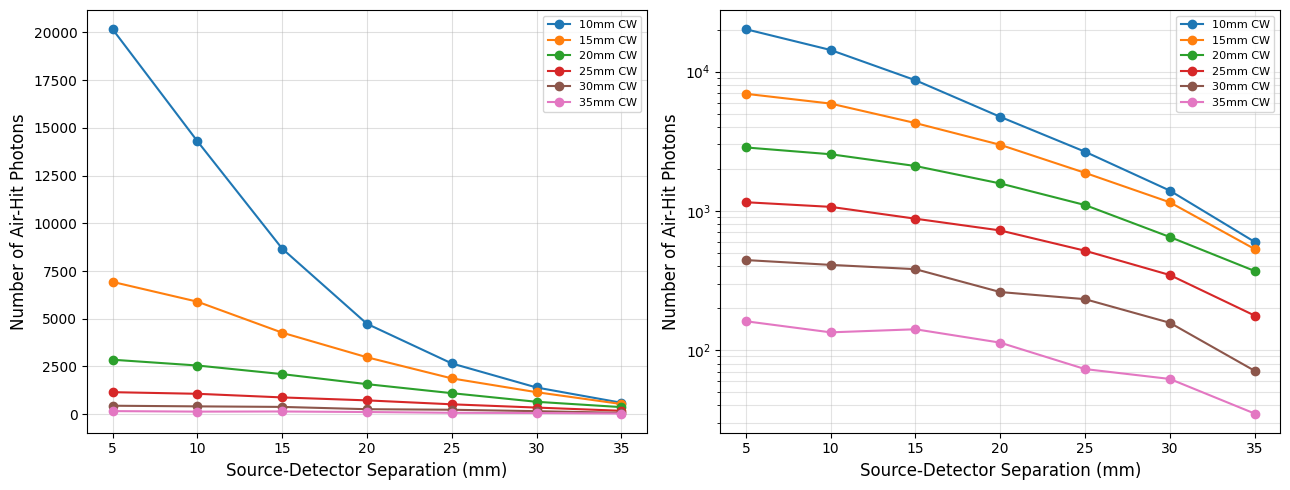

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    for cw in sorted(counts.keys()):
        sds_vals  = [r['sds']   for r in counts[cw]]
        air_vals  = [r['n_air'] for r in counts[cw]]
        ax.plot(sds_vals, air_vals, marker='o',
                color=CW_COLORS[cw], label=f'{cw} CW')
    ax.set_xlabel('Source-Detector Separation (mm)', fontsize=12)
    ax.set_ylabel('Number of Air-Hit Photons', fontsize=12)
    ax.set_yscale(yscale)
    #ax.set_title(f'Air-Hit Photon Counts vs. SDS  ({yscale} scale)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
    if yscale == 'log':
        ax.grid(True, which='both', alpha=0.35)

plt.tight_layout(); plt.show()

### 5c. Air-Hit Percentage vs. SDS  


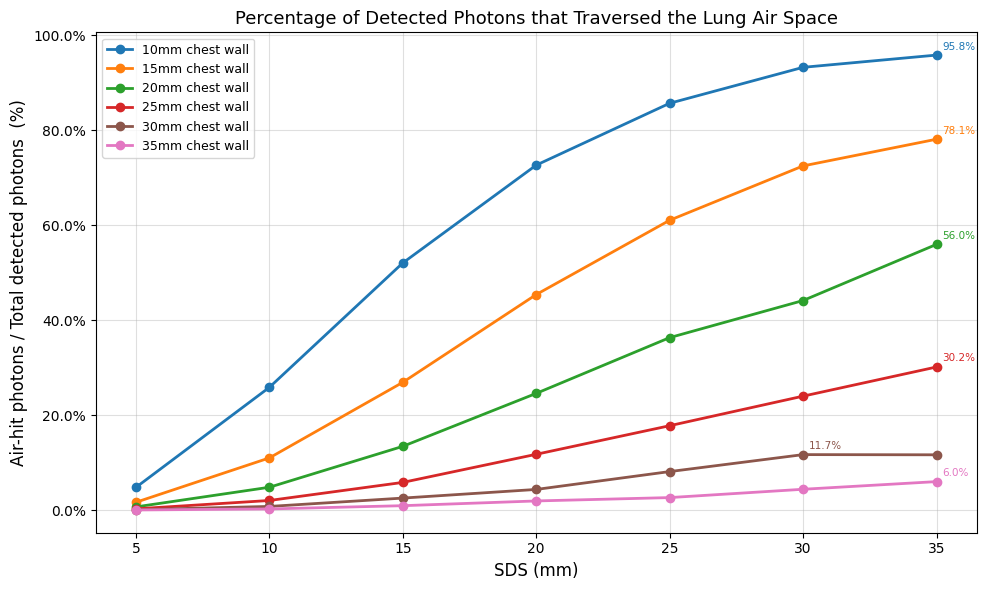

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for cw in sorted(counts.keys()):
    sds_vals = [r['sds']     for r in counts[cw]]
    pct_vals = [r['pct_air'] for r in counts[cw]]
    ax.plot(sds_vals, pct_vals, marker='o', lw=2,
            color=CW_COLORS[cw], label=f'{cw} chest wall')

    # Annotate peak
    peak_idx = int(np.argmax(pct_vals))
    ax.annotate(
        f"{pct_vals[peak_idx]:.1f}%",
        xy=(sds_vals[peak_idx], pct_vals[peak_idx]),
        xytext=(4, 4), textcoords='offset points',
        fontsize=7.5, color=CW_COLORS[cw]
    )

ax.set_xlabel('SDS (mm)', fontsize=12)
ax.set_ylabel('Air-hit photons / Total detected photons  (%)', fontsize=12)
ax.set_title('Percentage of Detected Photons that Traversed the Lung Air Space',
             fontsize=13)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


#### All-Layer Percentage Breakdown per Chest-Wall Thickness

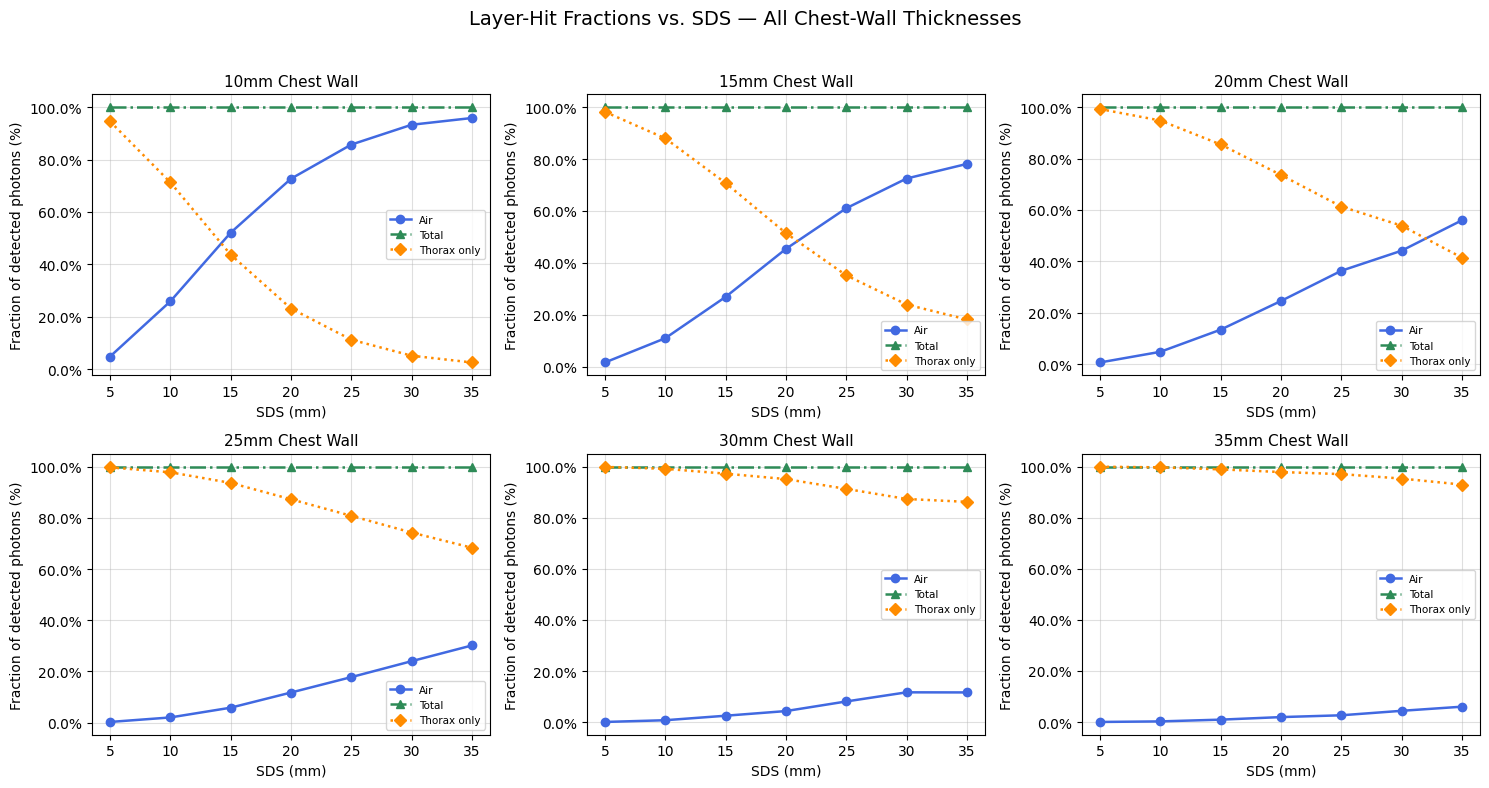

In [ ]:
cw_list = sorted(counts.keys())
n_cw    = len(cw_list)
cols    = 3;  rows = (n_cw + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), squeeze=False)
axes = axes.flatten()

layer_styles = [
    ('pct_air',          'Air',          'royalblue',  'o', '-'),
    #('pct_lung',         'Lung',         'tomato',     's', '--'),
    ('pct_thorax',       'Total',       'seagreen',   '^', '-.'),
    ('pct_thorax_only',  'Thorax only',  'darkorange',  'D', ':'),
]

for idx, cw in enumerate(cw_list):
    ax       = axes[idx]
    sds_vals = [r['sds'] for r in counts[cw]]
    for key, label, color, marker, ls in layer_styles:
        pct_vals = [r[key] for r in counts[cw]]
        ax.plot(sds_vals, pct_vals, marker=marker, ls=ls,
                color=color, label=label, lw=1.8)
    ax.set_title(f'{cw} Chest Wall', fontsize=11)
    ax.set_xlabel('SDS (mm)')
    ax.set_ylabel('Fraction of detected photons (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    ax.legend(fontsize=7.5); ax.grid(True, alpha=0.4)

for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Layer-Hit Fractions vs. SDS — All Chest-Wall Thicknesses',
             fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


### 5e. Thorax-Only Photon Counts vs. SDS

Photons confined to the chest wall represent background / noise photons —
they contribute to the DC signal but carry no GASMAS information.
Understanding their SDS dependence helps optimise the signal-to-background ratio.


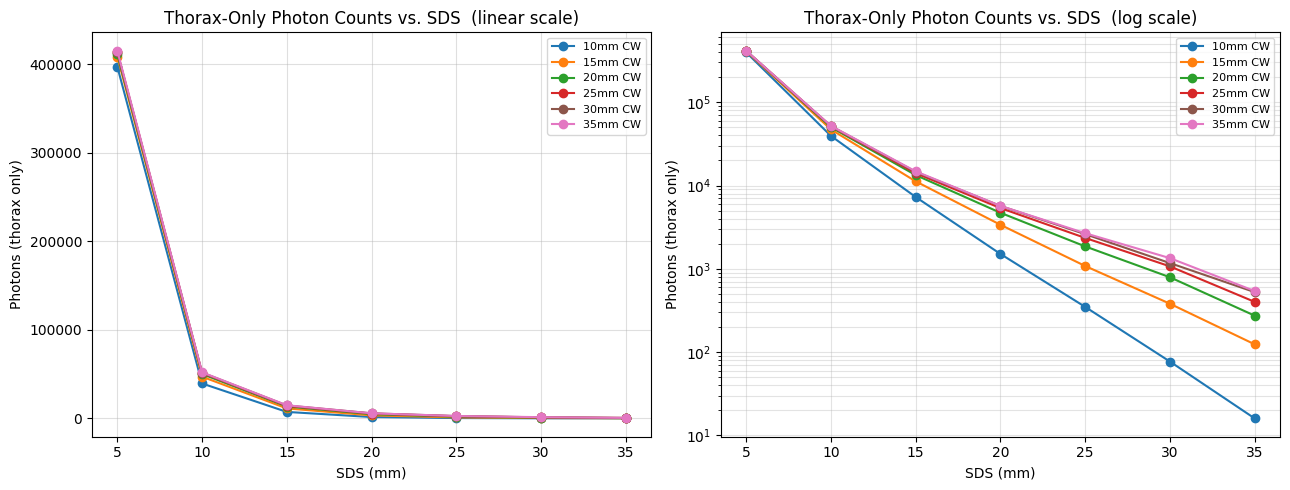

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    for cw in sorted(counts.keys()):
        sds_vals  = [r['sds']           for r in counts[cw]]
        tho_vals  = [r['n_thorax_only']  for r in counts[cw]]
        ax.plot(sds_vals, tho_vals, marker='o',
                color=CW_COLORS[cw], label=f'{cw} CW')
    ax.set_xlabel('SDS (mm)')
    ax.set_ylabel('Photons (thorax only)')
    ax.set_yscale(yscale)
    ax.set_title(f'Thorax-Only Photon Counts vs. SDS  ({yscale} scale)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
    if yscale == 'log':
        ax.grid(True, which='both', alpha=0.35)

plt.tight_layout(); plt.show()


## 6. Air-Hit Percentage Heatmap (CW Thickness × SDS)

A compact 2-D view of the air-hit fraction across the full parameter space.
Rows = chest-wall thickness, columns = SDS.
Darker blue cells indicate a higher fraction of GASMAS-signal-carrying photons.


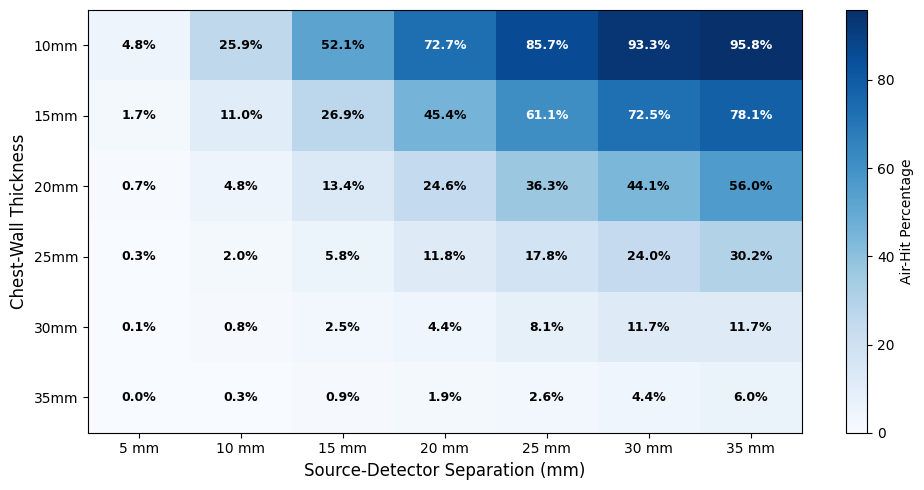

In [ ]:
cw_order  = sorted(counts.keys())   # 10mm … 35mm
n_cw      = len(cw_order)
n_sds     = len(SDS_LIST_MM)

heatmap = np.zeros((n_cw, n_sds))
for i, cw in enumerate(cw_order):
    for j, r in enumerate(counts[cw]):
        heatmap[i, j] = r['pct_air']

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heatmap, aspect='auto', cmap='Blues', vmin=0)

ax.set_xticks(range(n_sds))
ax.set_xticklabels([f'{s} mm' for s in SDS_LIST_MM])
ax.set_yticks(range(n_cw))
ax.set_yticklabels(cw_order)
ax.set_xlabel('Source-Detector Separation (mm)', fontsize=12)
ax.set_ylabel('Chest-Wall Thickness', fontsize=12)
#ax.set_title('Air-Hit Percentage Heatmap  (% of detected photons that traversed lung air)')

# Annotate cells with the value
for i in range(n_cw):
    for j in range(n_sds):
        val = heatmap[i, j]
        txt_color = 'white' if val > heatmap.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color=txt_color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Air-Hit Percentage')
plt.tight_layout(); plt.show()


## 7. Fluence study




In [ ]:
fl_30mm=fluence_raw['30mm']

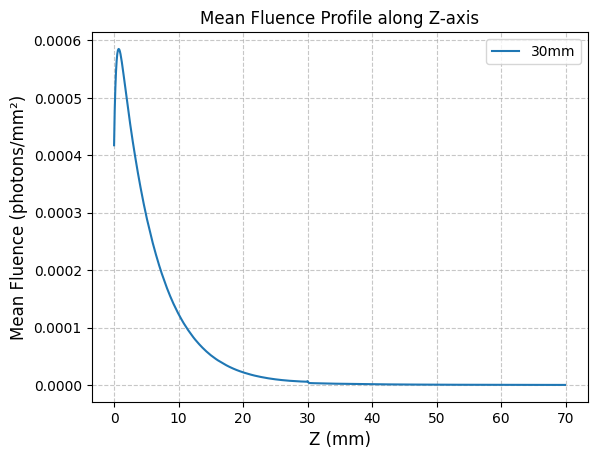

In [ ]:
depthprof_30mm = fl_30mm.mean(axis=(0, 1))
z_mm=np.arange(depthprof_30mm.shape[0])/10

plt.figure()
#plt.plot(depthprof_10mm, label='10mm')
#plt.plot(depthprof_20mm, label='20mm')
plt.plot(z_mm,depthprof_30mm, label='30mm')
plt.xlabel('Z (mm)', fontsize=12)
plt.ylabel('Mean Fluence (photons/mm²)', fontsize=12)
plt.title('Mean Fluence Profile along Z-axis', fontsize=12)
#plt.yscale('log') # Apply logarithmic scale as requested
plt.grid(True, which='both', ls='--', alpha=0.7)
plt.legend()
plt.show()

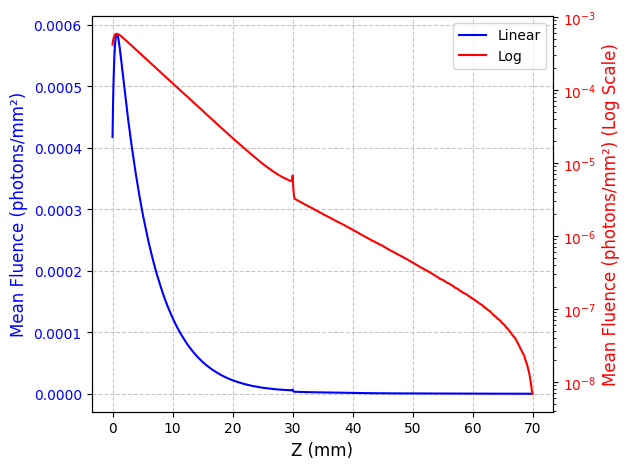

In [ ]:
depthprof_30mm = fl_30mm.mean(axis=(0, 1))

fig, ax1 = plt.subplots()

# Plot original fluence on the left y-axis
ax1.plot(z_mm,depthprof_30mm, label='Linear', color='blue')
ax1.set_xlabel('Z (mm)', fontsize=12)
ax1.set_ylabel('Mean Fluence (photons/mm²)', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
#ax1.set_title('Mean Fluence Profile along Z-axis', fontsize=12)
ax1.grid(True, which='both', ls='--', alpha=0.7)

# Create a second y-axis for the log scale
ax2 = ax1.twinx()
ax2.plot(z_mm,depthprof_30mm, label='Log', color='red', linestyle='-')
ax2.set_ylabel('Mean Fluence (photons/mm²) (Log Scale)', fontsize=12, color='red')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='red')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors

# Choose one chest-wall thickness for demonstration
cw_key = '30mm'
fluence_data = fluence_raw[cw_key]

# Get dimensions (assuming X, Y, Z order for fluence_raw output)
dim_x, dim_y, dim_z = fluence_data.shape

x_mm=np.arange(dim_x)/10
y_mm=np.arange(dim_y)/10

# --- Global Normalization --- START
# Calculate the maximum fluence in the entire 3D cube
global_max_fluence = np.max(fluence_data)

# Normalize the entire fluence dataset by the global maximum
# Handle case where global_max_fluence might be zero to avoid division by zero
if global_max_fluence == 0:
    print("Warning: Global maximum fluence is zero. Cannot normalize. Plotting raw data.")
    normalized_fluence_data = fluence_data
    plot_title = f'Raw Fluence Profile at Z=0 ({cw_key} CW)'
    cmap_label = 'Raw Fluence (a.u.)'
else:
    normalized_fluence_data = fluence_data / global_max_fluence
    plot_title = f'Normalized Fluence Profile at Z=0 (relative to global max) ({cw_key} CW)'
    cmap_label = 'Normalized Fluence (relative to global max)'
# --- Global Normalization --- END

# --- Extract Fluence Profile at Z=0 --- START
# User requested fluence profile at Z=0 (which corresponds to index 0 in 0-based indexing)
# Ensure z_index is within bounds
z_profile_idx = 0
if not (0 <= z_profile_idx < dim_z):
    print(f"Error: Z-profile index {z_profile_idx} is out of bounds for Z-dimension {dim_z}. Using z=0 instead.")
    z_profile_idx = 0

# Get the 2D fluence profile at the specified Z-index
display_fluence = normalized_fluence_data[:, :, z_profile_idx]
# --- Extract Fluence Profile at Z=0 --- END


# Plot the 2D colormap
fig, ax = plt.subplots()

# --- Logarithmic Colormap --- START
# Ensure there are no zero or negative values for LogNorm
# Replace zeros with a very small positive number or filter them out if appropriate
# A common practice for visualization is to set a minimum threshold for log scale.
min_val = np.min(display_fluence[display_fluence > 0]) if np.min(display_fluence[display_fluence > 0]) > 0 else 1e-10

im = ax.imshow(display_fluence, cmap='jet', origin='lower',
               extent=[x_mm.min(), x_mm.max(), y_mm.min(), y_mm.max()],
               norm=matplotlib.colors.LogNorm(vmin=min_val, vmax=display_fluence.max()))
# --- Logarithmic Colormap --- END

ax.set_xlabel('X (mm)', fontsize=12)
ax.set_ylabel('Y (mm)', fontsize=12)
ax.set_title(plot_title)
plt.colorbar(im, ax=ax, label=cmap_label)
plt.tight_layout()
plt.show()

NameError: name 'fluence_raw' is not defined

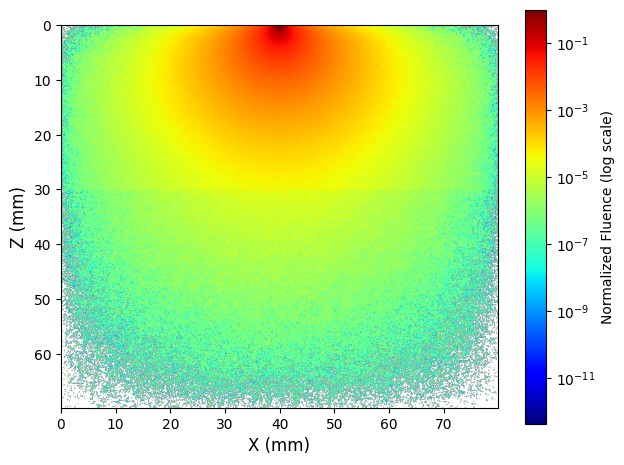

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors

# Choose one chest-wall thickness (e.g., '30mm')
cw_key = '30mm'
fluence_data = fluence_raw[cw_key]

# Get dimensions (assuming X, Y, Z order)
dim_x, dim_y, dim_z = fluence_data.shape

# Convert 40 cm to mm and then to voxel index
y_cm = 40
y_mm = y_cm * 10 # Assuming 1 voxel = 1 mm, adjust if your voxel size is different
y_index = int(y_mm) # Convert to integer index

# Ensure y_index is within bounds
if not (0 <= y_index < dim_y):
    print(f"Warning: Y-index {y_index} (from {y_cm} cm) is out of bounds for Y-dimension {dim_y}. Clamping to nearest valid index.")
    y_index = max(0, min(y_index, dim_y - 1))

# Extract the XZ cross-section at the specified Y-index
xz_cross_section = np.transpose(fluence_data[:, y_index, :])

# --- Global Normalization (optional, but good for consistent plots) ---
global_max_fluence = np.max(fluence_data)
if global_max_fluence == 0:
    print("Warning: Global maximum fluence is zero. Cannot normalize.")
    normalized_xz_cross_section = xz_cross_section
else:
    normalized_xz_cross_section = xz_cross_section / global_max_fluence

# Plot the 2D colormap for the XZ cross-section
fig, ax = plt.subplots()

# Ensure there are no zero or negative values for LogNorm
min_val = np.min(normalized_xz_cross_section[normalized_xz_cross_section > 0])
if min_val == 0: # If all non-zero values are zero, or no positive values exist
    min_val = 1e-10 # Set a very small positive number

im = ax.imshow(normalized_xz_cross_section, cmap='jet', origin='lower',
               extent=[x_mm.min(), x_mm.max(), z_mm.min(), z_mm.max()],
               norm=matplotlib.colors.LogNorm(vmin=min_val, vmax=normalized_xz_cross_section.max()))

ax.set_xlabel('X (mm)', fontsize=12)
ax.set_ylabel('Z (mm)', fontsize=12)
#ax.set_title(f'Fluence Profile: XZ Cross-Section at Y={y_cm} cm ({cw_key} CW)', fontsize=14)
plt.colorbar(im, ax=ax, label='Normalized Fluence (log scale)')
ax.invert_yaxis() # Reverse the y-axis (Z-axis) scale
plt.tight_layout()
plt.show()

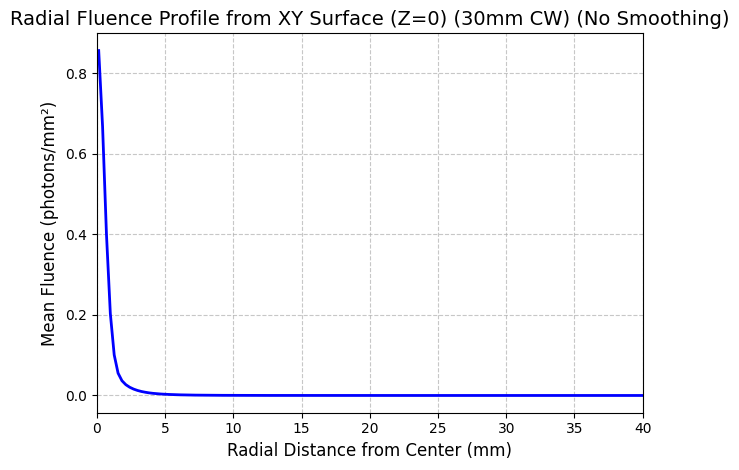

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import binned_statistic

# Assuming these variables are available from previous cells' execution context:
# fluence_raw, cw_key, display_fluence

# 1. Get image dimensions and define physical center
dim_x, dim_y = display_fluence.shape

# Define x_mm and y_mm as arrays representing physical coordinates
# Assuming 1 voxel = 1 mm, as implicitly used in other cells.
x_mm = np.arange(dim_x) / 10.0
y_mm = np.arange(dim_y) / 10.0

# Calculate the physical center of the displayed region
center_x_physical = (x_mm.min() + x_mm.max()) / 2.0
center_y_physical = (y_mm.min() + y_mm.max()) / 2.0

# Create a grid of physical coordinates for every point in the image
X_grid, Y_grid = np.meshgrid(x_mm, y_mm, indexing='ij')

# Calculate radial distance for each point from the physical center
R_grid = np.sqrt((X_grid - center_x_physical)**2 + (Y_grid - center_y_physical)**2)

# Flatten the arrays for binning
radial_distances = R_grid.flatten()
fluence_values = display_fluence.flatten()

# Filter out zero fluence values for radial profile calculation to avoid log(0) issues
# and focus on regions with actual photon presence
valid_indices = fluence_values > 0
radial_distances_valid = radial_distances[valid_indices]
fluence_values_valid = fluence_values[valid_indices]

# 2. Bin the valid fluence values by radial distance
# Determine bins. Max radius is from center to furthest corner.
max_radius = np.max(R_grid)
num_bins = 200 # A reasonable number of bins
radial_bins = np.linspace(0, max_radius, num_bins)
bin_centers = (radial_bins[:-1] + radial_bins[1:]) / 2

# Calculate mean fluence in each radial bin
radial_fluence_mean, _, _ = binned_statistic(radial_distances_valid, fluence_values_valid, statistic='mean', bins=radial_bins)

# Fill NaNs (for empty bins) with a very small positive number for plotting on log scale
radial_fluence_mean = np.nan_to_num(radial_fluence_mean, nan=1e-10)

# 3. Plot the radial profile without smoothing
fig, ax = plt.subplots()

ax.plot(bin_centers, radial_fluence_mean, lw=2, color='blue', label='Binned Mean Fluence')

ax.set_xlabel('Radial Distance from Center (mm)', fontsize=12)
ax.set_ylabel('Mean Fluence (photons/mm²)', fontsize=12)
ax.set_title(f'Radial Fluence Profile from XY Surface (Z=0) ({cw_key} CW) (No Smoothing)', fontsize=14)
#ax.set_yscale('log') # Use log scale for fluence
ax.set_xlim(0, 40) # Set x-axis limit to 400 mm (40 cm)
ax.grid(True, which='both', ls='--', alpha=0.7)
#ax.legend()
plt.tight_layout()
plt.show()

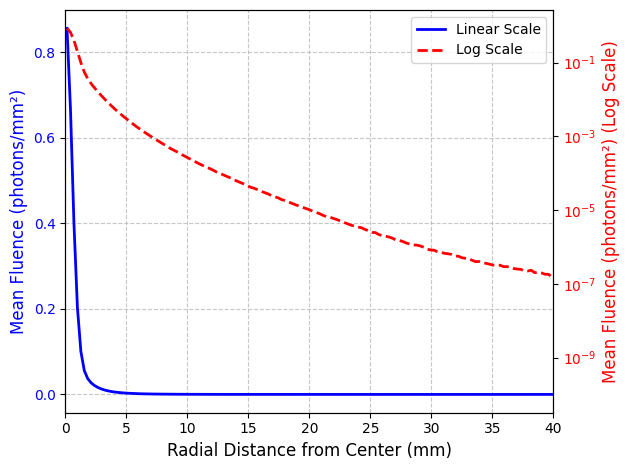

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import binned_statistic

# Assuming these variables are available from previous cells' execution context:
# fluence_raw, cw_key, display_fluence

# 1. Get image dimensions and define physical center
dim_x, dim_y = display_fluence.shape

# Define x_mm and y_mm as arrays representing physical coordinates
# Assuming 1 voxel = 1 mm, as implicitly used in other cells.
x_mm = np.arange(dim_x) / 10.0
y_mm = np.arange(dim_y) / 10.0

# Calculate the physical center of the displayed region
center_x_physical = (x_mm.min() + x_mm.max()) / 2.0
center_y_physical = (y_mm.min() + y_mm.max()) / 2.0

# Create a grid of physical coordinates for every point in the image
X_grid, Y_grid = np.meshgrid(x_mm, y_mm, indexing='ij')

# Calculate radial distance for each point from the physical center
R_grid = np.sqrt((X_grid - center_x_physical)**2 + (Y_grid - center_y_physical)**2)

# Flatten the arrays for binning
radial_distances = R_grid.flatten()
fluence_values = display_fluence.flatten()

# Filter out zero fluence values for radial profile calculation to avoid log(0) issues
# and focus on regions with actual photon presence
valid_indices = fluence_values > 0
radial_distances_valid = radial_distances[valid_indices]
fluence_values_valid = fluence_values[valid_indices]

# 2. Bin the valid fluence values by radial distance
# Determine bins. Max radius is from center to furthest corner.
max_radius = np.max(R_grid)
num_bins = 200 # A reasonable number of bins
radial_bins = np.linspace(0, max_radius, num_bins)
bin_centers = (radial_bins[:-1] + radial_bins[1:]) / 2

# Calculate mean fluence in each radial bin
radial_fluence_mean, _, _ = binned_statistic(radial_distances_valid, fluence_values_valid, statistic='mean', bins=radial_bins)

# Fill NaNs (for empty bins) with a very small positive number for plotting on log scale
radial_fluence_mean = np.nan_to_num(radial_fluence_mean, nan=1e-10)

# 3. Plot the radial profile with linear and log scales
fig, ax1 = plt.subplots()

# Plot linear scale on the left y-axis
ax1.plot(bin_centers, radial_fluence_mean, lw=2, color='blue', label='Linear Scale')
ax1.set_xlabel('Radial Distance from Center (mm)', fontsize=12)
ax1.set_ylabel('Mean Fluence (photons/mm²)', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
#ax1.set_title(f'Radial Fluence Profile from XY Surface (Z=0) ({cw_key} CW) (No Smoothing)', fontsize=14)
ax1.set_xlim(0, 40) # Set x-axis limit to 40 mm
ax1.grid(True, which='both', ls='--', alpha=0.7)

# Create a second y-axis for the log scale
ax2 = ax1.twinx()
ax2.plot(bin_centers, radial_fluence_mean, lw=2, color='red', linestyle='--', label='Log Scale')
ax2.set_ylabel('Mean Fluence (photons/mm²) (Log Scale)', fontsize=12, color='red')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='red')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()